In [2]:
import pandas as pd
import matplotlib.pyplot as plt




In [4]:
df = pd.read_csv("owid-covid-data.csv", usecols=['location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths'])


df_india = df[df['location'] == 'India'].copy()
df_india['date'] = pd.to_datetime(df_india['date'])

for col in ['total_cases', 'new_cases', 'total_deaths', 'new_deaths']:
    df_india[col] = pd.to_numeric(df_india[col]).fillna(0)



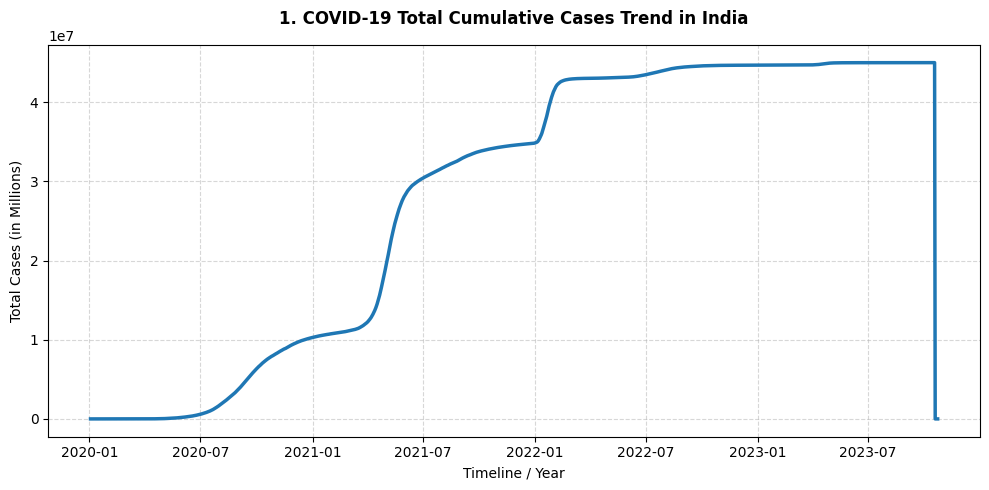

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df_india['date'], df_india['total_cases'], color='#1f77b4', linewidth=2.5)

plt.title('1. COVID-19 Total Cumulative Cases Trend in India', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline / Year', fontsize=10)
plt.ylabel('Total Cases (in Millions)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

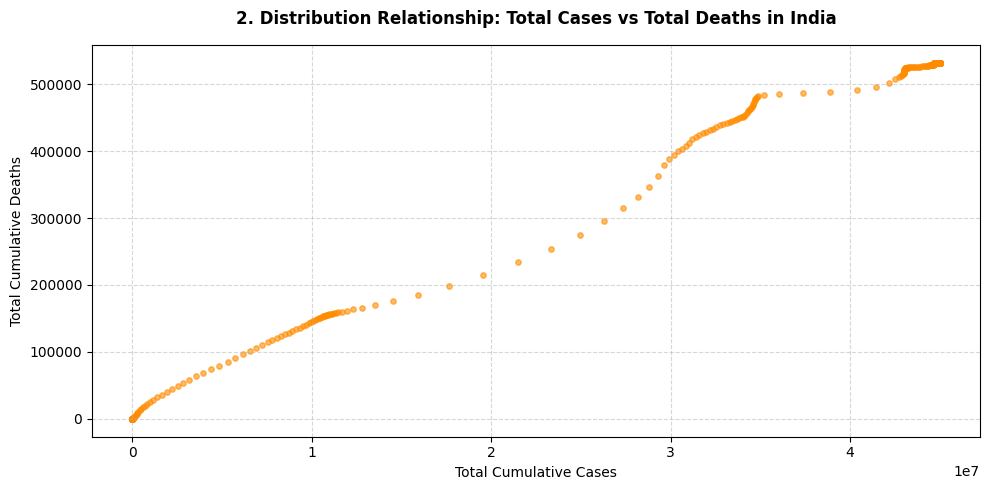

In [6]:
plt.figure(figsize=(10, 5))
df_sampled = df_india.iloc[::5]

plt.scatter(df_sampled['total_cases'], df_sampled['total_deaths'], color='darkorange', alpha=0.6, s=15)

plt.title('2. Distribution Relationship: Total Cases vs Total Deaths in India', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Cases', fontsize=10)
plt.ylabel('Total Cumulative Deaths', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

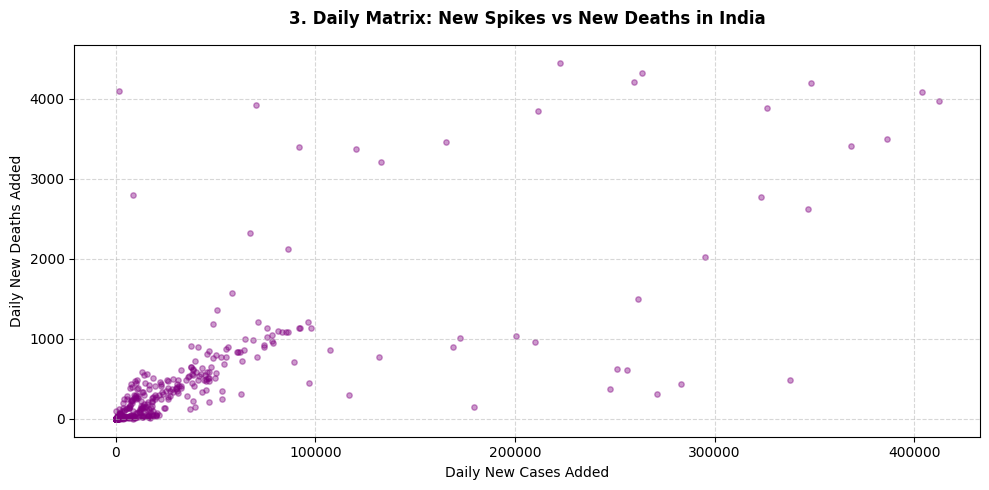

In [7]:
plt.figure(figsize=(10, 5))
df_daily_sampled = df_india.iloc[::3]

plt.scatter(df_daily_sampled['new_cases'], df_daily_sampled['new_deaths'], color='purple', alpha=0.4, s=15)

plt.title('3. Daily Matrix: New Spikes vs New Deaths in India', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Daily New Cases Added', fontsize=10)
plt.ylabel('Daily New Deaths Added', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

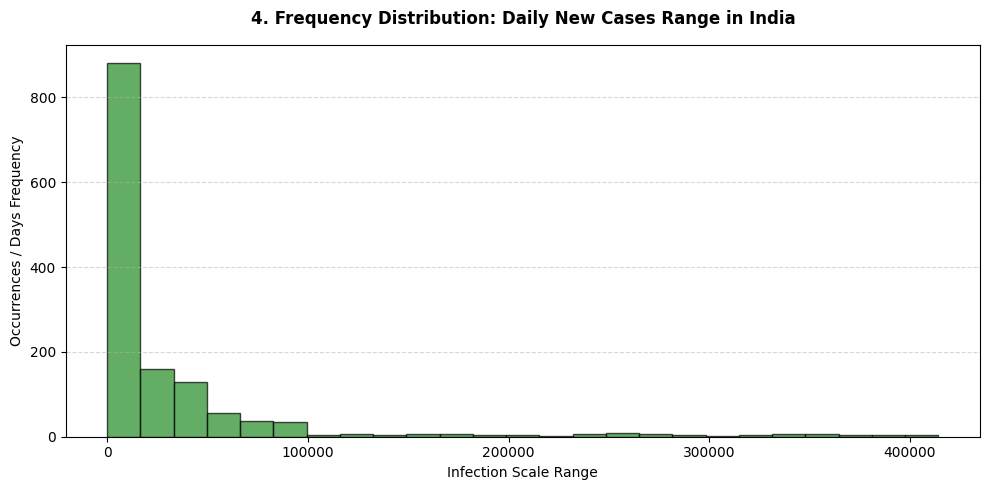

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df_india['new_cases'], bins=25, color='forestgreen', edgecolor='black', alpha=0.7)

plt.title('4. Frequency Distribution: Daily New Cases Range in India', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Infection Scale Range', fontsize=10)
plt.ylabel('Occurrences / Days Frequency', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

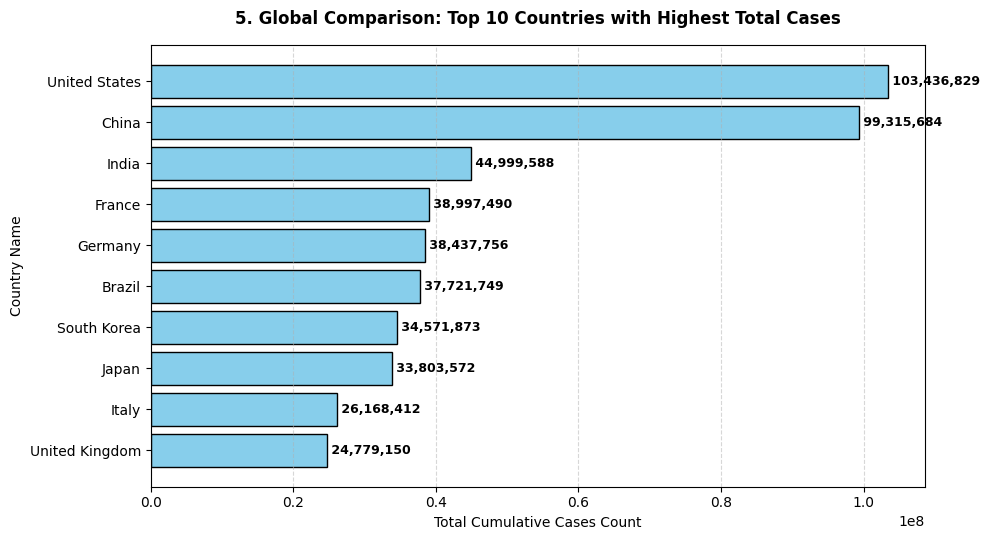

In [12]:

aggregates = ['World', 'High income', 'Europe', 'Asia', 'North America', 'South America', 'European Union', 'Lower middle income', 'Upper middle income']
df_countries = df[~df['location'].isin(aggregates)]

df_global_top10 = df_countries.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5.5))
plt.barh(df_global_top10['location'], df_global_top10['total_cases'], color='skyblue', edgecolor='black')


for i, val in enumerate(df_global_top10['total_cases']):
    plt.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=9)

plt.title('5. Global Comparison: Top 10 Countries with Highest Total Cases', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Cases Count', fontsize=10)
plt.ylabel('Country Name', fontsize=10)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:

df_india.to_csv("cleaned_covid_data.csv", index=False)


In [14]:
plt.savefig('my_chart.png', dpi=300) 
plt.show()

<Figure size 640x480 with 0 Axes>